# **HEART-DISEASE CLASSIFICATION MODEL**

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('heart_disease_data.csv')

In [3]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.62376

In [11]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_7560\4135644844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['target'], palette="coolwarm")


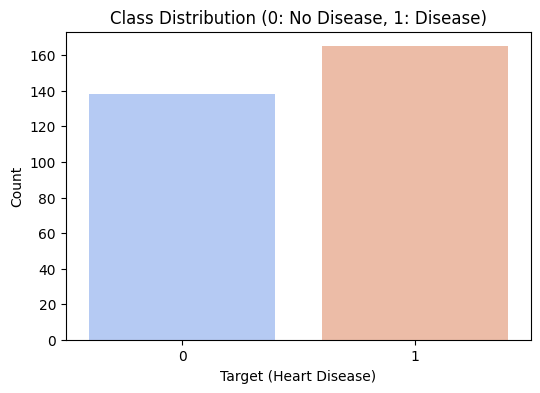

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df['target'], palette="coolwarm")
plt.title("Class Distribution (0: No Disease, 1: Disease)")
plt.xlabel("Target (Heart Disease)")
plt.ylabel("Count")
plt.show()

In [5]:
df = pd.get_dummies(df, columns=['cp', 'thal', 'slope'], drop_first=True)


In [6]:
X = df.drop(columns=['target'])
y = df['target']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

C:\Users\dell\AppData\Local\Temp\ipykernel_7560\3743057254.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="coolwarm")


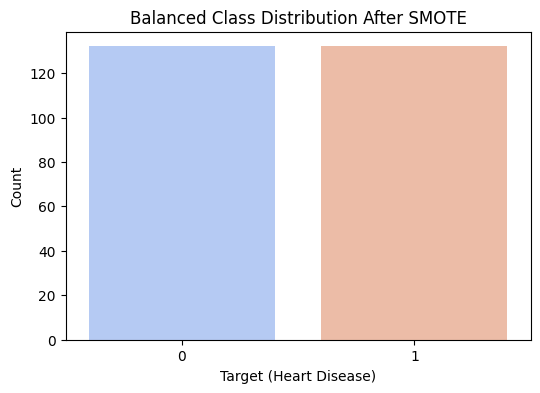

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette="coolwarm")
plt.title("Balanced Class Distribution After SMOTE")
plt.xlabel("Target (Heart Disease)")
plt.ylabel("Count")
plt.show()

In [11]:
model = keras.Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [12]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [14]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), callbacks=[early_stopping])


Epoch 1/50


17/17 [==============================] - 7s 58ms/step - loss: 1.7152 - accuracy: 0.4205 - val_loss: 1.6071 - val_accuracy: 0.5082
Epoch 2/50
17/17 [==============================] - 0s 16ms/step - loss: 1.6513 - accuracy: 0.5114 - val_loss: 1.5927 - val_accuracy: 0.5246
Epoch 3/50
17/17 [==============================] - 0s 15ms/step - loss: 1.6102 - accuracy: 0.5341 - val_loss: 1.5761 - val_accuracy: 0.5574
Epoch 4/50
17/17 [==============================] - 0s 13ms/step - loss: 1.5991 - accuracy: 0.5341 - val_loss: 1.5601 - val_accuracy: 0.5902
Epoch 5/50
17/17 [==============================] - 0s 18ms/step - loss: 1.5623 - accuracy: 0.5720 - val_loss: 1.5426 - val_accuracy: 0.6066
Epoch 6/50
17/17 [==============================] - 0s 14ms/step - loss: 1.5461 - accuracy: 0.5455 - val_loss: 1.5268 - val_accuracy: 0.6230
Epoch 7/50
17/17 [==============================] - 0s 17ms/step - loss: 1.5202 - accuracy: 0.6250 - val_loss: 1.5068 - val_accuracy: 0.6393
Epoch 8/50


In [15]:
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred_nn))

2/2 [==============================] - 1s 12ms/step
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



In [16]:
print("Model Input Shape:", model.input_shape)


Model Input Shape: (None, 18)


In [17]:
# Save the model to a file
model.save('heart_disease.h5')


c:\Users\dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [20]:
joblib.dump(scaler, 'heart_disease_scaler.pkl')


['heart_disease_scaler.pkl']

In [21]:
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred_nn))

2/2 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0       0.86      0.64      0.73        28
           1       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



In [22]:

new_data = pd.DataFrame({
    'age': [40, 55, 62, 47, 59, 53, 64, 44, 70, 50],
    'sex': [1, 0, 1, 0, 1, 1, 0, 1, 1, 0],
    'trestbps': [120, 135, 140, 128, 138, 125, 145, 118, 150, 130],
    'chol': [210, 240, 260, 220, 280, 245, 300, 200, 310, 225],
    'fbs': [0, 1, 0, 0, 1, 0, 1, 0, 1, 0],
    'restecg': [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    'thalach': [175, 160, 150, 170, 145, 165, 140, 180, 135, 168],
    'exang': [0, 1, 0, 0, 1, 0, 1, 0, 1, 0],
    'oldpeak': [0.5, 1.8, 2.0, 0.0, 2.5, 0.8, 3.0, 0.3, 3.5, 1.0],
    'cp_1': [1, 0, 1, 0, 0, 1, 0, 1, 0, 1],
    'cp_2': [0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    'cp_3': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'thal_2': [0, 1, 0, 0, 1, 0, 1, 0, 1, 0],
    'thal_3': [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    'thal_4': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'slope_1': [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    'slope_2': [0, 1, 0, 0, 1, 0, 1, 0, 1, 0]
})



In [23]:
missing_cols = set(X.columns) - set(new_data.columns)
for col in missing_cols:
    new_data[col] = 0

In [24]:
new_data = new_data[X.columns]


In [25]:
new_data_scaled = scaler.transform(new_data)


In [26]:
predictions = model.predict(new_data_scaled)


1/1 [==============================] - 0s 57ms/step


In [27]:
predicted_classes = (predictions > 0.5).astype(int)


In [28]:
for i, pred in enumerate(predicted_classes):
    result = "Heart Disease" if pred == 1 else "No Heart Disease"
    print(f"Sample {i+1}: Predicted Class - {result}")

Sample 1: Predicted Class - Heart Disease
Sample 2: Predicted Class - Heart Disease
Sample 3: Predicted Class - No Heart Disease
Sample 4: Predicted Class - Heart Disease
Sample 5: Predicted Class - Heart Disease
Sample 6: Predicted Class - Heart Disease
Sample 7: Predicted Class - Heart Disease
Sample 8: Predicted Class - Heart Disease
Sample 9: Predicted Class - Heart Disease
Sample 10: Predicted Class - Heart Disease
